# League Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

model_aliases = {
    "fixed_2p": "DQN Fixed",
    "fixed_3p": "DQN Fixed",
    "fixed_4p": "DQN Fixed",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
    "random": "Random",
}
model_order = ["DQN Fixed", "DQN Variable", "DQN Variable + Encoder", "Random"]

result_roots = [Path("results/league_results"), Path("../../results/league_results")]
results_root = next(path for path in result_roots if path.exists())

frames = []
for player_count in (2, 3, 4):
    path = results_root / f"{player_count}p" / "matches.csv"
    if not path.exists():
        continue
    data = pd.read_csv(path)
    data["player_count"] = player_count
    frames.append(data)

df = pd.concat(frames, ignore_index=True)
def split_pipe(value):
    return str(value).split("|")

def mean_pipe_ints(value):
    values = [int(part) for part in split_pipe(value)]
    return sum(values) / len(values)

df["competitor_label"] = df["competitor"].map(model_aliases)
df["opponent_labels"] = df["opponent_competitors"].apply(
    lambda names: [model_aliases[name] for name in split_pipe(names)]
)
df["opponent_mean_points"] = df["opponent_points_all"].apply(mean_pipe_ints)
df["point_margin"] = df["points"] - df["opponent_mean_points"]
df["won"] = df["outcome"].eq("win")
df["player_count_label"] = df["player_count"].astype(str) + "p"

## Results Loaded

In [2]:
loaded = (
    df.groupby("player_count")
      .agg(rows=("match_id", "size"), games=("match_id", "nunique"), matchups=("matchup_id", "nunique"))
      .reset_index()
)
loaded

,player_count,rows,games,matchups
0,2,7200,3600,36
1,3,24300,8100,81
2,4,50400,12600,126


## Overall Results

In [3]:
overall = (
    df.groupby(["player_count", "competitor_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
overall.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,games,wins,losses,ties,raw_win_rate,mean_points,mean_margin
0,2,DQN Fixed,2400,1093,1286,21,45.5%,55.63,-0.81
1,2,DQN Variable,2400,1042,1325,33,43.4%,55.35,-1.37
2,2,DQN Variable + Encoder,2400,1425,949,26,59.4%,57.32,+2.18
3,3,DQN Fixed,8100,2554,5454,92,31.5%,45.97,-0.25
4,3,DQN Variable,8100,2559,5465,76,31.6%,45.85,-0.30
5,3,DQN Variable + Encoder,8100,2864,5155,81,35.4%,46.59,+0.55
6,4,DQN Fixed,16800,4357,12246,197,25.9%,39.04,+0.29
7,4,DQN Variable,16800,3871,12748,181,23.0%,38.50,-0.40
8,4,DQN Variable + Encoder,16800,4095,12526,179,24.4%,38.97,+0.11


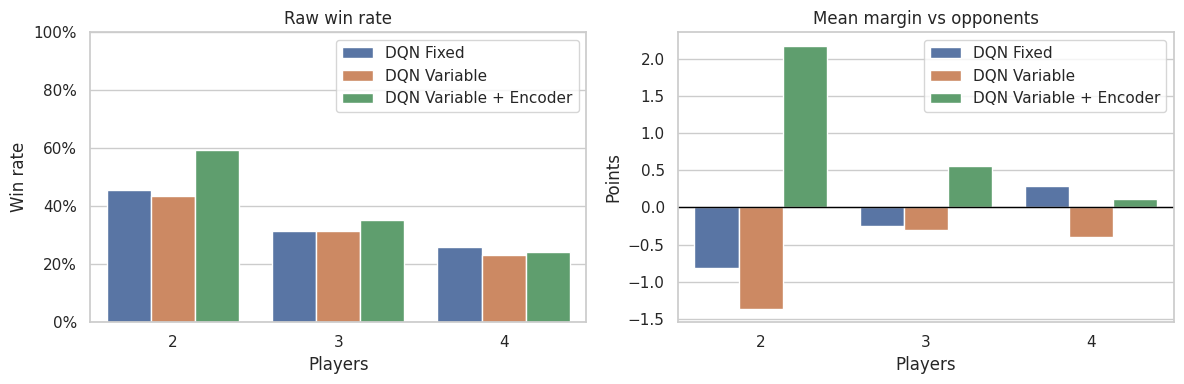

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=overall,
    x="player_count",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Raw win rate")
axes[0].set_xlabel("Players")
axes[0].set_ylabel("Win rate")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

sns.barplot(
    data=overall,
    x="player_count",
    y="mean_margin",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Mean margin vs opponents")
axes[1].set_xlabel("Players")
axes[1].set_ylabel("Points")

for ax in axes:
    ax.legend(title="")
plt.tight_layout()

## Matchup View

In [5]:
opponent_rows = []
for row in df.itertuples(index=False):
    for opponent_label in row.opponent_labels:
        opponent_rows.append({
            "player_count": row.player_count,
            "competitor_label": row.competitor_label,
            "opponent_label": opponent_label,
            "won": row.won,
            "point_margin": row.point_margin,
        })

opponent_df = pd.DataFrame(opponent_rows)
matchup_summary = (
    opponent_df.groupby(["player_count", "competitor_label", "opponent_label"])
      .agg(
          rows=("won", "size"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
matchup_summary.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,opponent_label,rows,raw_win_rate,mean_margin
0,2,DQN Fixed,DQN Fixed,600,50.0%,+0.00
1,2,DQN Fixed,DQN Variable,900,50.2%,+0.54
2,2,DQN Fixed,DQN Variable + Encoder,900,37.9%,-2.71
3,2,DQN Variable,DQN Fixed,900,48.3%,-0.54
4,2,DQN Variable,DQN Variable,600,49.3%,+0.00
5,2,DQN Variable,DQN Variable + Encoder,900,34.6%,-3.10
6,2,DQN Variable + Encoder,DQN Fixed,900,61.2%,+2.71
7,2,DQN Variable + Encoder,DQN Variable,900,64.1%,+3.10
8,2,DQN Variable + Encoder,DQN Variable + Encoder,600,49.5%,+0.00
9,3,DQN Fixed,DQN Fixed,3600,32.2%,-0.14


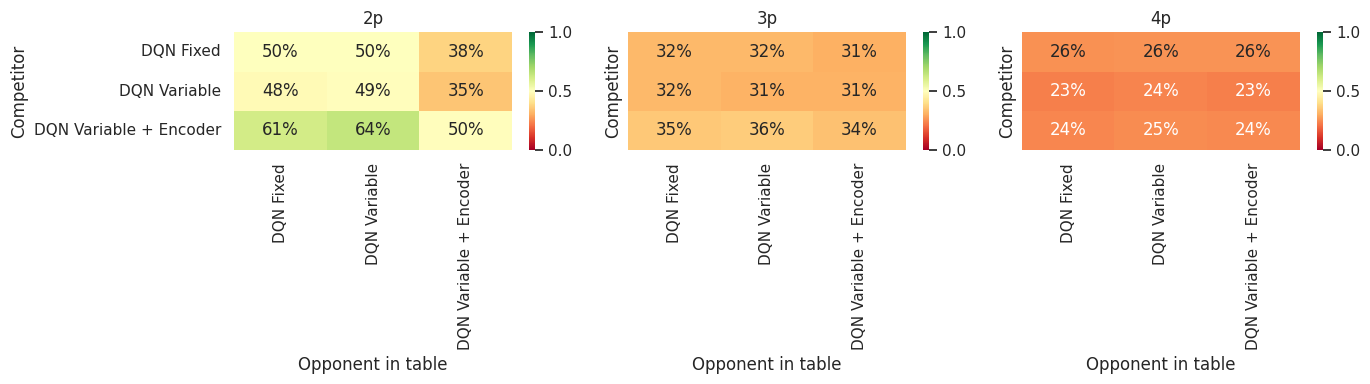

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, player_count in zip(axes, (2, 3, 4)):
    matrix = matchup_summary[matchup_summary["player_count"] == player_count].pivot(
        index="competitor_label", columns="opponent_label", values="raw_win_rate"
    ).reindex(index=model_order, columns=model_order)
    sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=ax)
    ax.set_title(f"{player_count}p")
    ax.set_xlabel("Opponent in table")
    ax.set_ylabel("Competitor")
plt.tight_layout()

## Repetition Variance

In [7]:
repetition_win_rates = (
    df.groupby(["player_count", "competitor_label", "repetition"])
      .agg(games=("match_id", "size"), raw_win_rate=("won", "mean"))
      .reset_index()
)

win_rate_variance = (
    repetition_win_rates.groupby(["player_count", "competitor_label"])
      .agg(
          repetitions=("repetition", "nunique"),
          mean_win_rate=("raw_win_rate", "mean"),
          win_rate_variance=("raw_win_rate", "var"),
      )
      .reset_index()
)
win_rate_variance["win_rate_variance"] = win_rate_variance["win_rate_variance"].fillna(0)
win_rate_variance.style.format({
    "mean_win_rate": "{:.1%}",
    "win_rate_variance": "{:.4f}",
})

,player_count,competitor_label,repetitions,mean_win_rate,win_rate_variance
0,2,DQN Fixed,3,45.5%,0.0012
1,2,DQN Variable,3,43.4%,0.0010
2,2,DQN Variable + Encoder,3,59.4%,0.0027
3,3,DQN Fixed,3,31.5%,0.0008
4,3,DQN Variable,3,31.6%,0.0002
5,3,DQN Variable + Encoder,3,35.4%,0.0002
6,4,DQN Fixed,3,25.9%,0.0000
7,4,DQN Variable,3,23.0%,0.0002
8,4,DQN Variable + Encoder,3,24.4%,0.0003


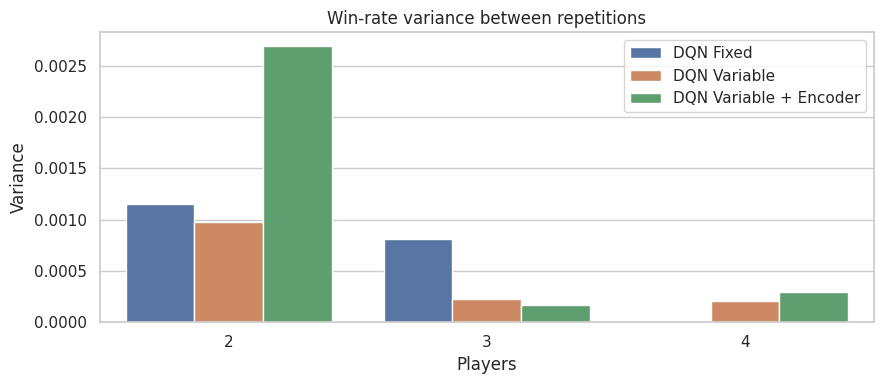

In [8]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=win_rate_variance,
    x="player_count",
    y="win_rate_variance",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
)
plt.title("Win-rate variance between repetitions")
plt.xlabel("Players")
plt.ylabel("Variance")
plt.legend(title="")
plt.tight_layout()

## Seat Effects

In [9]:
seat_results = (
    df.groupby(["player_count", "competitor_label", "seat"])
      .agg(
          games=("match_id", "size"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
seat_results.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,seat,games,raw_win_rate,mean_margin
0,2,DQN Fixed,0,1235,46.3%,-0.70
1,2,DQN Fixed,1,1165,44.7%,-0.93
2,2,DQN Variable,0,1199,43.5%,-1.47
3,2,DQN Variable,1,1201,43.4%,-1.26
4,2,DQN Variable + Encoder,0,1166,60.1%,+2.16
5,2,DQN Variable + Encoder,1,1234,58.7%,+2.20
6,3,DQN Fixed,0,2657,31.2%,-0.32
7,3,DQN Fixed,1,2751,32.1%,-0.25
8,3,DQN Fixed,2,2692,31.3%,-0.20
9,3,DQN Variable,0,2766,30.8%,-0.41


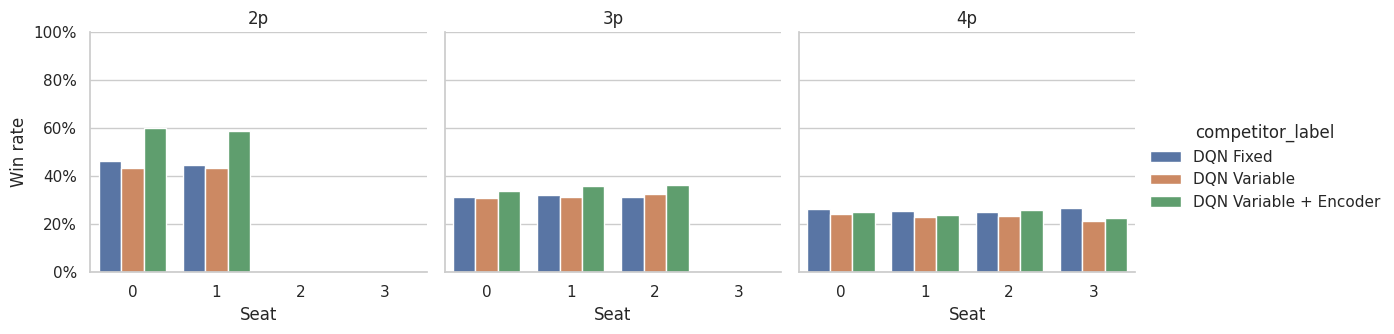

In [10]:
grid = sns.catplot(
    data=seat_results,
    kind="bar",
    x="seat",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    col="player_count",
    errorbar=None,
    height=3.5,
    aspect=1.1,
)
grid.set_axis_labels("Seat", "Win rate")
grid.set_titles("{col_name}p")
for ax in grid.axes.flat:
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

## Training Metrics

In [ ]:
metrics_candidates = [Path("results/league"), Path("../../results/league")]
metrics_root = next(path for path in metrics_candidates if path.exists())

checkpoint_aliases = {
    "fixed_2p": "DQN Fixed 2 Players",
    "fixed_3p": "DQN Fixed 3 Players",
    "fixed_4p": "DQN Fixed 4 Players",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
}

training_metrics = []
for model, alias in checkpoint_aliases.items():
    for metrics_path in sorted((metrics_root / model).glob("repetition_*/metrics.csv")):
        metrics = pd.read_csv(metrics_path)
        metrics["checkpoint"] = alias
        metrics["repetition"] = int(metrics_path.parent.name.removeprefix("repetition_"))
        training_metrics.append(metrics)

training_df = pd.concat(training_metrics, ignore_index=True)
training_df["loss_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["loss"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)
training_df["return_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["mean_episode_return"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)

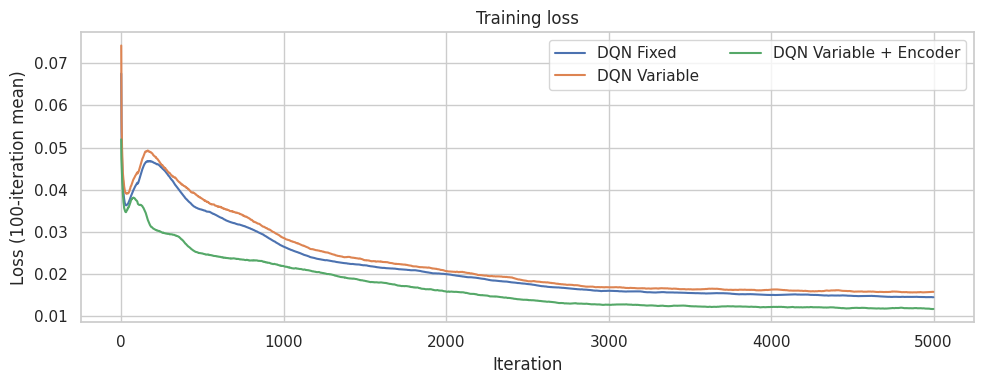

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="loss_smoothed", hue="checkpoint")
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()

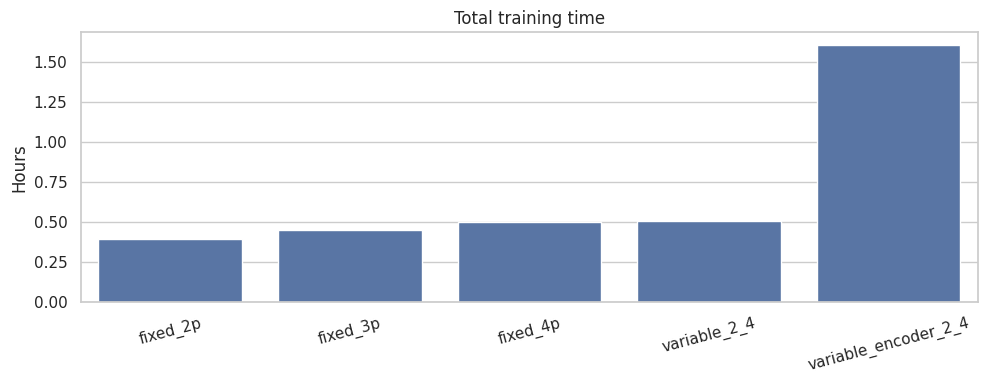

In [ ]:
training_time = training_df.groupby(["checkpoint", "repetition"], as_index=False)["elapsed_seconds"].max()
training_time["hours"] = training_time["elapsed_seconds"] / 3600

plt.figure(figsize=(10, 4))
sns.barplot(data=training_time, x="checkpoint", y="hours")
plt.title("Total training time")
plt.xlabel("")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.tight_layout()

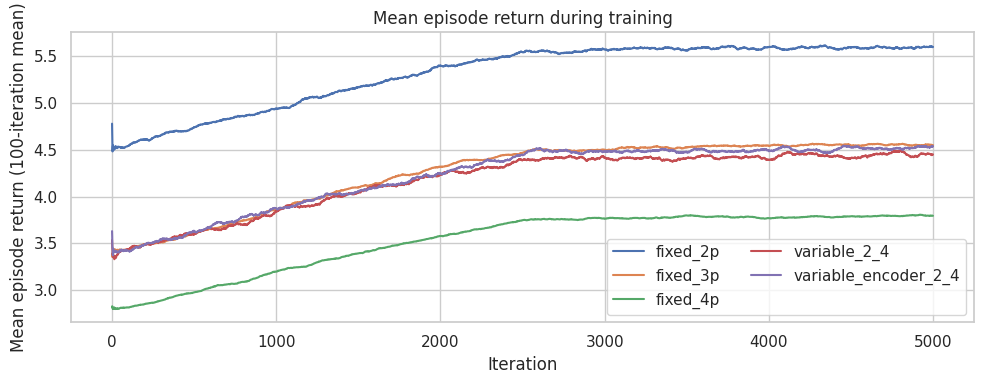

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="return_smoothed", hue="checkpoint")
plt.title("Mean episode return during training")
plt.xlabel("Iteration")
plt.ylabel("Mean episode return (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()